# 04 — Feature Engineering (Kalimantan Development)

This notebook performs the **feature engineering** stage after Notebook 03.

**Development scope:** Kalimantan only.  
After the final pipeline and method are determined, the pipeline will be generalized to **Kalimantan + Sumatra**.

## Main principles

This notebook **does not repeat raw hourly weather/AQ preprocessing** because the daily tables are already available in:

```text
data/intermediate/
├── weather_kalimantan_rich_daily.csv
└── aq_kalimantan_rich_daily.csv
```

Notebook 04 focuses on:

1. Load the fire cell-day panel from Notebook 03.
2. Create 10 leakage-safe Fire History features.
3. Load the existing daily weather data.
4. Load the existing daily AQ data as candidate features.
5. Menggabungkan seluruh data.
6. Audit missing values, duplicates, temporal continuity, and leakage.
7. Produce the 20-feature benchmark dataset for Notebook 05.

## Forecasting task

For each cell and day `t`:

> use information available up to day `t` to predict whether fire activity will be observed on day `t+1`.

Target:

```text
target_fire_active_t1 = fire_active on day t+1
```

### Fire History — 10 features

```text
fire_count_lag1
fire_count_lag3
fire_count_lag7
frp_sum_lag1
frp_sum_lag3
frp_sum_lag7
fire_count_roll3
fire_count_roll7
frp_sum_roll3
frp_sum_roll7
```

### Weather — 10 benchmark features

```text
temperature_mean
temperature_max
relative_humidity_mean
precipitation_sum
boundary_layer_height_mean
vapour_pressure_deficit_mean
wind_speed_mean
wind_speed_max
wind_u_mean
wind_v_mean
```

### AQ — optional candidate features

```text
pm2_5_mean
pm2_5_max
aerosol_optical_depth_mean
carbon_monoxide_mean
formaldehyde_mean
```

AQ is not automatically included in the 20-feature benchmark. Notebook 05 will evaluate it separately through controlled ablation.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent

INTERMEDIATE_DIR = PROJECT_ROOT / "data" / "intermediate"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FIRE_INPUT = INTERMEDIATE_DIR / "fire_kalimantan_cell_day_full.csv"
WEATHER_INPUT = INTERMEDIATE_DIR / "weather_kalimantan_rich_daily.csv"
AQ_INPUT = INTERMEDIATE_DIR / "aq_kalimantan_rich_daily.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Fire input   :", FIRE_INPUT)
print("Weather input:", WEATHER_INPUT)
print("AQ input     :", AQ_INPUT)


Project root : c:\Users\Asus\Documents\skripsi-karhut
Fire input   : c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\fire_kalimantan_cell_day_full.csv
Weather input: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\weather_kalimantan_rich_daily.csv
AQ input     : c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\aq_kalimantan_rich_daily.csv


## 1. Check required intermediate files

This notebook intentionally reuses the existing preprocessing outputs so that the pipeline does not repeat the same work twice.


In [4]:
required_files = {
    "fire": FIRE_INPUT,
    "weather": WEATHER_INPUT,
    "aq": AQ_INPUT
}

for name, path in required_files.items():
    print(f"{name:8s} | exists={path.exists()} | {path}")

missing_files = [
    str(path) for path in required_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required intermediate file(s) not found:\n" +
        "\n".join(missing_files)
    )


fire     | exists=True | c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\fire_kalimantan_cell_day_full.csv
weather  | exists=True | c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\weather_kalimantan_rich_daily.csv
aq       | exists=True | c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\aq_kalimantan_rich_daily.csv


## 2. Load the fire cell-day panel from Notebook 03


In [5]:
fire = pd.read_csv(
    FIRE_INPUT,
    parse_dates=["date"]
)

print("Fire panel shape:", fire.shape)
print(
    "Date range:",
    fire["date"].min().date(),
    "→",
    fire["date"].max().date()
)
print("Unique cells:", fire["cell_id"].nunique())

display(fire.head())


Fire panel shape: (36448, 11)
Date range: 2026-05-01 → 2026-09-11
Unique cells: 272


,region,cell_id,grid_lat,grid_lon,date,fire_count,frp_sum,frp_mean,frp_max,fire_active,target_fire_active_t1
0,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-01,0.0,0.0,0.0,0.0,0.0,0.0
1,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-02,0.0,0.0,0.0,0.0,0.0,0.0
2,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-03,0.0,0.0,0.0,0.0,0.0,0.0
3,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-04,0.0,0.0,0.0,0.0,0.0,0.0
4,Kalimantan,Kalimantan_-0.75_108.00,-0.75,108.0,2026-05-05,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
required_fire_cols = {
    "region",
    "cell_id",
    "grid_lat",
    "grid_lon",
    "date",
    "fire_count",
    "frp_sum",
    "frp_mean",
    "frp_max",
    "fire_active",
    "target_fire_active_t1"
}

missing_fire_cols = required_fire_cols - set(fire.columns)

if missing_fire_cols:
    raise ValueError(
        f"Missing columns from Notebook 03 output: {sorted(missing_fire_cols)}"
    )

fire = (
    fire
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

duplicate_fire = fire.duplicated(
    ["cell_id", "date"]
).sum()

print("Duplicate cell-date rows:", duplicate_fire)

if duplicate_fire:
    raise ValueError("Duplicate cell-date rows found in fire panel.")


Duplicate cell-date rows: 0


## 3. Fire History Feature Engineering

**Important:** rolling features are calculated after `shift(1)`.

Contoh:

```text
day t:
    lag1  = fire_count(t-1)
    roll3 = fire_count(t-1) + fire_count(t-2) + fire_count(t-3)
    roll7 = fire_count(t-1) + ... + fire_count(t-7)
```

Therefore, the features do not use the fire observation from day t itself.


In [7]:
# Explicit lag features.
for source_col in ["fire_count", "frp_sum"]:
    for lag in [1, 3, 7]:
        fire[f"{source_col}_lag{lag}"] = (
            fire.groupby("cell_id")[source_col]
            .shift(lag)
        )

# Shift first, then rolling.
shifted_fire_count = (
    fire.groupby("cell_id")["fire_count"]
    .shift(1)
)

shifted_frp_sum = (
    fire.groupby("cell_id")["frp_sum"]
    .shift(1)
)

fire["fire_count_roll3"] = (
    shifted_fire_count
    .groupby(fire["cell_id"])
    .rolling(window=3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
)

fire["fire_count_roll7"] = (
    shifted_fire_count
    .groupby(fire["cell_id"])
    .rolling(window=7, min_periods=7)
    .sum()
    .reset_index(level=0, drop=True)
)

fire["frp_sum_roll3"] = (
    shifted_frp_sum
    .groupby(fire["cell_id"])
    .rolling(window=3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
)

fire["frp_sum_roll7"] = (
    shifted_frp_sum
    .groupby(fire["cell_id"])
    .rolling(window=7, min_periods=7)
    .sum()
    .reset_index(level=0, drop=True)
)

fire_history_features = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

print("Fire History features:", len(fire_history_features))
display(
    fire[
        [
            "cell_id",
            "date",
            "fire_count",
            "frp_sum",
            "fire_count_lag1",
            "fire_count_lag3",
            "fire_count_lag7",
            "fire_count_roll3",
            "fire_count_roll7",
            "target_fire_active_t1"
        ]
    ].head(15)
)


Fire History features: 10


,cell_id,date,fire_count,frp_sum,fire_count_lag1,fire_count_lag3,fire_count_lag7,fire_count_roll3,fire_count_roll7,target_fire_active_t1
0,Kalimantan_-0.75_108.00,2026-05-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0
1,Kalimantan_-0.75_108.00,2026-05-02,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
2,Kalimantan_-0.75_108.00,2026-05-03,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0
3,Kalimantan_-0.75_108.00,2026-05-04,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
4,Kalimantan_-0.75_108.00,2026-05-05,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
5,Kalimantan_-0.75_108.00,2026-05-06,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
6,Kalimantan_-0.75_108.00,2026-05-07,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
7,Kalimantan_-0.75_108.00,2026-05-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Kalimantan_-0.75_108.00,2026-05-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Kalimantan_-0.75_108.00,2026-05-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Fire History leakage checks

We verify programmatically that:
- lag 1 exactly matches the previous day;
- rolling 3 and rolling 7 do not include the current day.


In [8]:
# Lag-1 exact check.
expected_lag1 = (
    fire.groupby("cell_id")["fire_count"]
    .shift(1)
)

lag1_mismatch = (
    ~np.isclose(
        fire["fire_count_lag1"].fillna(-999),
        expected_lag1.fillna(-999)
    )
).sum()

print("Lag-1 mismatches:", lag1_mismatch)

if lag1_mismatch:
    raise ValueError("Lag-1 feature alignment failed.")


Lag-1 mismatches: 0


In [9]:
# Rolling checks on rows where a full window exists.
manual_count = fire.groupby("cell_id")["fire_count"].shift(1)

expected_roll3 = (
    manual_count
    .groupby(fire["cell_id"])
    .rolling(3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
)

expected_roll7 = (
    manual_count
    .groupby(fire["cell_id"])
    .rolling(7, min_periods=7)
    .sum()
    .reset_index(level=0, drop=True)
)

roll3_mask = fire["fire_count_roll3"].notna()
roll7_mask = fire["fire_count_roll7"].notna()

roll3_mismatch = (
    ~np.isclose(
        fire.loc[roll3_mask, "fire_count_roll3"],
        expected_roll3.loc[roll3_mask]
    )
).sum()

roll7_mismatch = (
    ~np.isclose(
        fire.loc[roll7_mask, "fire_count_roll7"],
        expected_roll7.loc[roll7_mask]
    )
).sum()

print("Roll-3 mismatches:", roll3_mismatch)
print("Roll-7 mismatches:", roll7_mismatch)

if roll3_mismatch or roll7_mismatch:
    raise ValueError("Rolling feature alignment failed.")


Roll-3 mismatches: 0
Roll-7 mismatches: 0


## 5. Load precomputed daily weather

`weather_kalimantan_rich_daily.csv` is already the aggregated daily table derived from hourly rich weather.

We do not repeat the pivot and daily aggregation in this notebook.


In [10]:
weather = pd.read_csv(
    WEATHER_INPUT,
    parse_dates=["date"]
)

print("Weather daily shape:", weather.shape)
print(
    "Date range:",
    weather["date"].min().date(),
    "→",
    weather["date"].max().date()
)

display(weather.head())


Weather daily shape: (13400, 14)
Date range: 2026-05-01 → 2026-09-11


,lat,lon,date,temperature_mean,temperature_max,relative_humidity_mean,precipitation_sum,boundary_layer_height_mean,vapour_pressure_deficit_mean,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,wind_direction_mean
0,-4.5,108.00,2026-05-01,28.883333,29.9,75.625000,4.4,539.583333,0.974583,8.704167,15.7,-5.855721,6.052841,135.948323
1,-4.5,109.25,2026-05-01,28.841667,29.7,75.916667,3.1,561.041667,0.966667,11.100000,20.2,-6.622832,8.406283,141.767437
2,-4.5,110.50,2026-05-01,28.512500,29.9,77.791667,6.2,480.208333,0.870417,11.212500,17.4,-6.560133,7.913294,140.341216
3,-4.5,111.75,2026-05-01,28.675000,29.9,76.708333,9.3,561.875000,0.919583,13.595833,20.0,-8.896947,9.165566,135.852020
4,-4.5,113.00,2026-05-01,28.491667,29.7,76.750000,2.2,585.625000,0.908333,11.833333,18.1,-6.177314,6.958956,138.405231


In [11]:
weather_features = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

missing_weather_features = set(weather_features) - set(weather.columns)

if missing_weather_features:
    raise ValueError(
        f"Missing weather features: {sorted(missing_weather_features)}"
    )

weather = weather.rename(columns={
    "lat": "weather_lat",
    "lon": "weather_lon"
})

weather_duplicate = weather.duplicated(
    ["date", "weather_lat", "weather_lon"]
).sum()

print("Duplicate weather date-grid rows:", weather_duplicate)

if weather_duplicate:
    raise ValueError("Duplicate weather date-grid rows found.")


Duplicate weather date-grid rows: 0


## 6. Map fire cells to nearest weather cell

Notebook 03 uses a 0.75° fire/AQ grid, while weather uses a 1.25° grid.

The mapping uses **Haversine distance** and is created once per fire cell.


In [12]:
fire_cells = (
    fire[
        ["cell_id", "grid_lat", "grid_lon"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

weather_cells = (
    weather[
        ["weather_lat", "weather_lon"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Fire cells:", len(fire_cells))
print("Weather cells:", len(weather_cells))


Fire cells: 272
Weather cells: 100


In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


mapping_rows = []

weather_lat_values = weather_cells["weather_lat"].to_numpy()
weather_lon_values = weather_cells["weather_lon"].to_numpy()

for row in fire_cells.itertuples(index=False):

    distances = haversine_km(
        row.grid_lat,
        row.grid_lon,
        weather_lat_values,
        weather_lon_values
    )

    nearest_idx = np.argmin(distances)

    mapping_rows.append({
        "cell_id": row.cell_id,
        "grid_lat": row.grid_lat,
        "grid_lon": row.grid_lon,
        "weather_lat": weather_cells.iloc[nearest_idx]["weather_lat"],
        "weather_lon": weather_cells.iloc[nearest_idx]["weather_lon"],
        "weather_distance_km": distances[nearest_idx]
    })

weather_mapping = pd.DataFrame(mapping_rows)

print("Mapping rows:", len(weather_mapping))
display(weather_mapping.head())


Mapping rows: 272


,cell_id,grid_lat,grid_lon,weather_lat,weather_lon,weather_distance_km
0,Kalimantan_-0.75_108.00,-0.75,108.00,-0.75,108.00,0.000000
1,Kalimantan_-0.75_108.75,-0.75,108.75,-0.75,109.25,55.592777
2,Kalimantan_-0.75_109.50,-0.75,109.50,-0.75,109.25,27.796388
3,Kalimantan_-0.75_110.25,-0.75,110.25,-0.75,110.50,27.796388
4,Kalimantan_-0.75_111.00,-0.75,111.00,-0.75,110.50,55.592777


In [14]:
print("Weather mapping distance summary:")
display(weather_mapping["weather_distance_km"].describe())

print(
    "Max distance   :",
    round(weather_mapping["weather_distance_km"].max(), 2),
    "km"
)
print(
    "Mean distance  :",
    round(weather_mapping["weather_distance_km"].mean(), 2),
    "km"
)
print(
    "Median distance:",
    round(weather_mapping["weather_distance_km"].median(), 2),
    "km"
)


Weather mapping distance summary:


count    272.000000
mean      52.102367
std       22.410552
min        0.000000
25%       39.227045
50%       55.597540
75%       62.154103
max       99.992151
Name: weather_distance_km, dtype: float64

Max distance   : 99.99 km
Mean distance  : 52.1 km
Median distance: 55.6 km


## 7. Merge fire history + weather



In [15]:
feature_df = fire.merge(
    weather_mapping[
        [
            "cell_id",
            "weather_lat",
            "weather_lon",
            "weather_distance_km"
        ]
    ],
    on="cell_id",
    how="left",
    validate="many_to_one"
)

feature_df = feature_df.merge(
    weather[
        ["date", "weather_lat", "weather_lon"] + weather_features
    ],
    on=["date", "weather_lat", "weather_lon"],
    how="left",
    validate="many_to_one"
)

print("After weather merge:", feature_df.shape)


After weather merge: (36448, 34)


In [16]:
weather_missing_rows = (
    feature_df[weather_features]
    .isna()
    .any(axis=1)
    .sum()
)

print("Rows with missing weather features:", weather_missing_rows)

if weather_missing_rows:
    display(
        feature_df[
            feature_df[weather_features].isna().any(axis=1)
        ][
            ["date", "cell_id", "weather_lat", "weather_lon"]
            + weather_features
        ].head(20)
    )


Rows with missing weather features: 0


## 8. Load precomputed daily AQ candidate features

AQ daily data are also already available. We do not repeat the hourly → daily aggregation.

AQ is used as an **optional candidate group** for Notebook 05, not as part of the main benchmark.


In [17]:
aq = pd.read_csv(
    AQ_INPUT,
    parse_dates=["date"]
)

print("AQ daily shape:", aq.shape)
print(
    "Date range:",
    aq["date"].min().date(),
    "→",
    aq["date"].max().date()
)

display(aq.head())


AQ daily shape: (36448, 8)
Date range: 2026-05-01 → 2026-09-11


,lat,lon,date,pm2_5_mean,pm2_5_max,aerosol_optical_depth_mean,carbon_monoxide_mean,formaldehyde_mean
0,-4.5,108.00,2026-05-01,5.762500,6.8,0.147500,130.833333,0.841667
1,-4.5,108.75,2026-05-01,4.583333,7.2,0.136250,122.916667,0.625000
2,-4.5,109.50,2026-05-01,6.291667,9.1,0.190000,141.750000,0.695833
3,-4.5,110.25,2026-05-01,4.000000,5.3,0.168333,139.166667,0.670833
4,-4.5,111.00,2026-05-01,3.287500,4.4,0.120417,114.208333,0.629167


In [18]:
aq_features = [
    "pm2_5_mean",
    "pm2_5_max",
    "aerosol_optical_depth_mean",
    "carbon_monoxide_mean",
    "formaldehyde_mean"
]

missing_aq_features = set(aq_features) - set(aq.columns)

if missing_aq_features:
    raise ValueError(
        f"Missing AQ candidate features: {sorted(missing_aq_features)}"
    )

aq = aq.rename(columns={
    "lat": "grid_lat",
    "lon": "grid_lon"
})

aq_duplicate = aq.duplicated(
    ["date", "grid_lat", "grid_lon"]
).sum()

print("Duplicate AQ date-grid rows:", aq_duplicate)

if aq_duplicate:
    raise ValueError("Duplicate AQ date-grid rows found.")


Duplicate AQ date-grid rows: 0


## 9. Merge optional AQ candidates

Because the AQ grid is the same as the fire grid, the join is performed using:

```text
date + grid_lat + grid_lon
```


In [19]:
feature_df = feature_df.merge(
    aq[
        ["date", "grid_lat", "grid_lon"] + aq_features
    ],
    on=["date", "grid_lat", "grid_lon"],
    how="left",
    validate="many_to_one"
)

print("After AQ merge:", feature_df.shape)

print("Missing AQ candidate values:")
display(
    feature_df[aq_features]
    .isna()
    .sum()
    .to_frame("missing")
)


After AQ merge: (36448, 39)
Missing AQ candidate values:


,missing
pm2_5_mean,0
pm2_5_max,0
aerosol_optical_depth_mean,0
carbon_monoxide_mean,0
formaldehyde_mean,0


## 10. Define benchmark feature set

The main benchmark must use the **same 20 features** for every model so that model comparisons are fair.

```text
10 Fire History
+
10 Weather
=
20 Benchmark Features
```

AQ will be evaluated separately through ablation.


In [20]:
benchmark_features = (
    fire_history_features
    + weather_features
)

assert len(fire_history_features) == 10
assert len(weather_features) == 10
assert len(benchmark_features) == 20

print("Benchmark features:", len(benchmark_features))

for i, feature in enumerate(benchmark_features, start=1):
    print(f"{i:02d}. {feature}")


Benchmark features: 20
01. fire_count_lag1
02. fire_count_lag3
03. fire_count_lag7
04. frp_sum_lag1
05. frp_sum_lag3
06. frp_sum_lag7
07. fire_count_roll3
08. fire_count_roll7
09. frp_sum_roll3
10. frp_sum_roll7
11. temperature_mean
12. temperature_max
13. relative_humidity_mean
14. precipitation_sum
15. boundary_layer_height_mean
16. vapour_pressure_deficit_mean
17. wind_speed_mean
18. wind_speed_max
19. wind_u_mean
20. wind_v_mean


## 11. Create final benchmark dataset

Lag/rolling 7 requires at least 7 days of history.

In addition, the final date for each cell has no t+1 target.

We only drop rows that cannot be used for the benchmark.


In [21]:
before_drop = len(feature_df)

model_df = (
    feature_df
    .dropna(
        subset=benchmark_features + ["target_fire_active_t1"]
    )
    .copy()
    .sort_values(["cell_id", "date"])
    .reset_index(drop=True)
)

print("Rows before drop:", before_drop)
print("Rows after drop :", len(model_df))
print("Rows removed    :", before_drop - len(model_df))

print(
    "Date range:",
    model_df["date"].min().date(),
    "→",
    model_df["date"].max().date()
)

print("Unique cells:", model_df["cell_id"].nunique())


Rows before drop: 36448
Rows after drop : 34272
Rows removed    : 2176
Date range: 2026-05-08 → 2026-09-10
Unique cells: 272


## 12. Final leakage audit

The target must not be used as a feature.

Selain itu:
- `fire_count` and `fire_active` from day t are not benchmark features;
- lag/rolling features come from t-1 or earlier;
- weather represents conditions on day t for predicting t+1;
- AQ candidates also represent conditions on day t and are not part of the main benchmark.


In [22]:
# Target exclusion.
assert "target_fire_active_t1" not in benchmark_features

# Current-day fire exclusion.
assert "fire_count" not in benchmark_features
assert "fire_active" not in benchmark_features

# Required feature completeness.
assert not model_df[benchmark_features].isna().any().any()

# Target completeness.
assert not model_df["target_fire_active_t1"].isna().any()

print("Basic feature/target leakage checks: PASSED")


Basic feature/target leakage checks: PASSED


## 13. Verify target = next-day fire activity



In [23]:
expected_target = (
    model_df
    .groupby("cell_id")["fire_active"]
    .shift(-1)
)

# The final row of each cell should have no next-day target.
# Those rows were already removed from model_df.
valid_target_check = expected_target.notna()

target_mismatch = (
    model_df.loc[valid_target_check, "target_fire_active_t1"].to_numpy()
    != expected_target.loc[valid_target_check].to_numpy()
).sum()

print("Target mismatches:", target_mismatch)

if target_mismatch:
    raise ValueError("Target alignment check failed.")

print("Target = next-day fire_active: PASSED")


Target mismatches: 0
Target = next-day fire_active: PASSED


## 14. Temporal continuity check

Each cell must have a 1-day interval throughout the model dataset.


In [24]:
continuity = []

for cell_id, group in model_df.groupby("cell_id"):

    dates = group["date"].sort_values()
    diffs = dates.diff().dropna().dt.days

    continuity.append({
        "cell_id": cell_id,
        "rows": len(group),
        "min_gap_days": diffs.min() if len(diffs) else np.nan,
        "max_gap_days": diffs.max() if len(diffs) else np.nan,
        "gap_count": int((diffs != 1).sum())
    })

continuity = pd.DataFrame(continuity)

print(
    "Cells with temporal gaps:",
    (continuity["gap_count"] > 0).sum()
)

print(
    "Maximum gap:",
    continuity["max_gap_days"].max()
)

if (continuity["gap_count"] > 0).any():
    display(continuity[continuity["gap_count"] > 0].head())
    raise ValueError("Temporal gaps detected.")


Cells with temporal gaps: 0
Maximum gap: 1


## 15. Target distribution


In [25]:
target_distribution = (
    model_df["target_fire_active_t1"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
    * 100
)

display(target_distribution)


,count,percentage
target_fire_active_t1,,
0.0,27990,81.670168
1.0,6282,18.329832


## 16. Feature statistics


In [26]:
feature_summary = (
    model_df[benchmark_features]
    .describe()
    .T
)

feature_summary["missing"] = (
    model_df[benchmark_features]
    .isna()
    .sum()
)

display(feature_summary)


,count,mean,std,min,25%,50%,75%,max,missing
fire_count_lag1,34272.0,4.049516,28.185368,0.000000,0.000000,0.000000,0.000000,1288.000000,0
fire_count_lag3,34272.0,3.922998,27.892771,0.000000,0.000000,0.000000,0.000000,1288.000000,0
fire_count_lag7,34272.0,3.568306,26.646265,0.000000,0.000000,0.000000,0.000000,1288.000000,0
frp_sum_lag1,34272.0,32.519474,248.691400,0.000000,0.000000,0.000000,0.000000,13504.440000,0
frp_sum_lag3,34272.0,31.982217,248.208694,0.000000,0.000000,0.000000,0.000000,13504.440000,0
frp_sum_lag7,34272.0,29.301654,237.512786,0.000000,0.000000,0.000000,0.000000,13504.440000,0
fire_count_roll3,34272.0,11.963264,78.576723,0.000000,0.000000,0.000000,1.000000,3291.000000,0
fire_count_roll7,34272.0,26.887080,169.706121,0.000000,0.000000,0.000000,3.000000,5647.000000,0
frp_sum_roll3,34272.0,96.821962,661.516199,0.000000,0.000000,0.000000,2.490000,25662.680000,0
frp_sum_roll7,34272.0,218.714177,1381.653206,0.000000,0.000000,0.000000,11.600000,39301.210000,0


## 17. Correlation diagnostic

This is only a diagnostic, **not feature selection**.


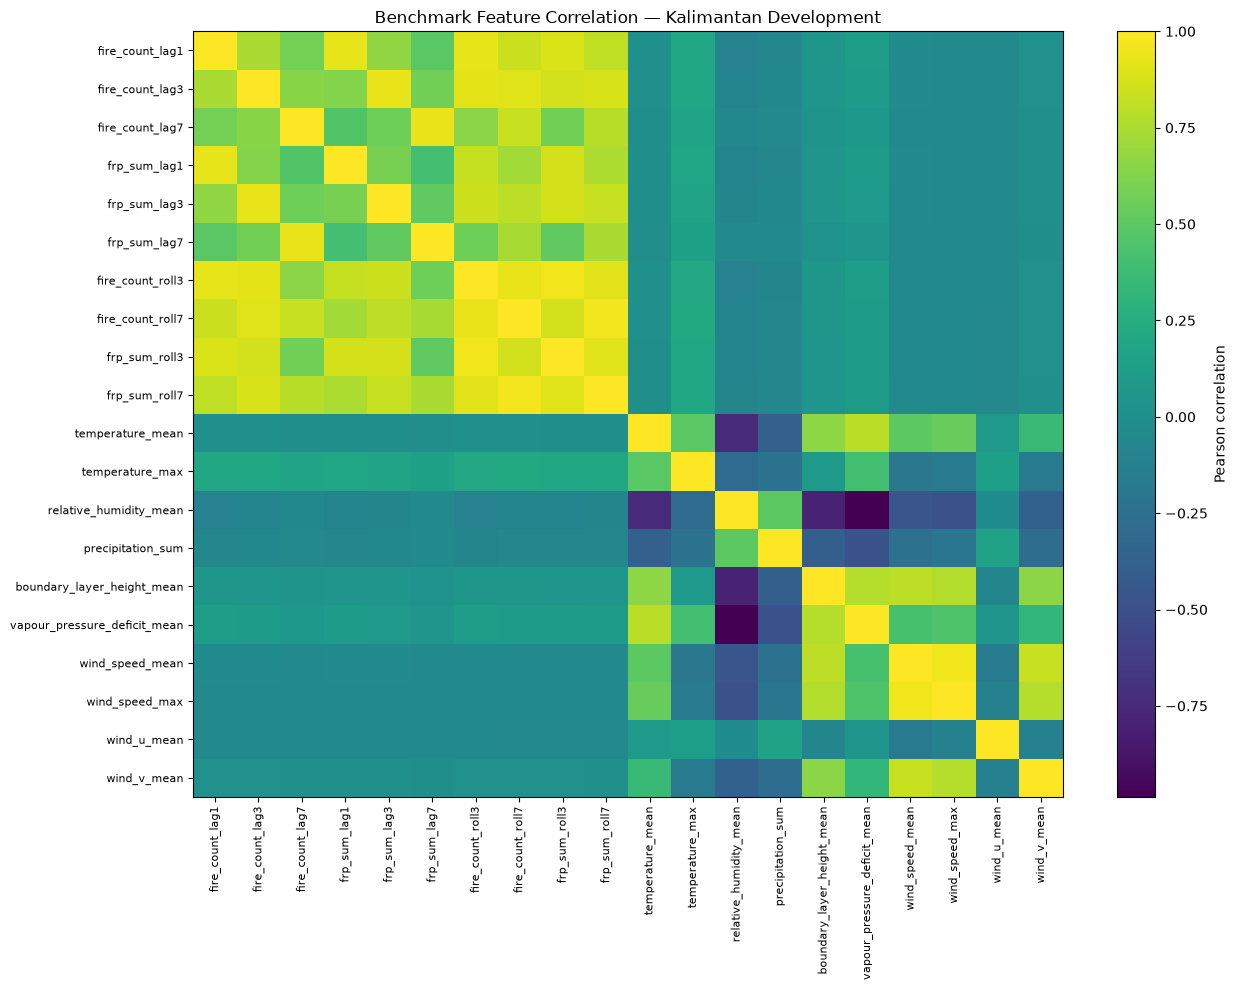

In [27]:
corr = model_df[benchmark_features].corr()

plt.figure(figsize=(13, 10))

plt.imshow(
    corr,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(benchmark_features)),
    benchmark_features,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(benchmark_features)),
    benchmark_features,
    fontsize=8
)

plt.title("Benchmark Feature Correlation — Kalimantan Development")
plt.tight_layout()
plt.show()


## 18. Save outputs

Main output:

```text
data/processed/
├── karhut_ml_dataset_kalimantan.csv
├── karhut_ml_master_kalimantan.csv
└── karhut_ml_aq_candidates_kalimantan.csv
```

`karhut_ml_dataset_kalimantan.csv` is the 20-feature benchmark dataset for Notebook 05.


In [28]:
benchmark_columns = [
    "region",
    "cell_id",
    "date",
    "grid_lat",
    "grid_lon",
    "weather_lat",
    "weather_lon",
    "weather_distance_km"
] + benchmark_features + ["target_fire_active_t1"]

benchmark_df = model_df[benchmark_columns].copy()

master_output = PROCESSED_DIR / "karhut_ml_master_kalimantan.csv"
benchmark_output = PROCESSED_DIR / "karhut_ml_dataset_kalimantan.csv"
aq_output = PROCESSED_DIR / "karhut_ml_aq_candidates_kalimantan.csv"

model_df.to_csv(
    master_output,
    index=False
)

benchmark_df.to_csv(
    benchmark_output,
    index=False
)

aq_output_df = model_df[
    [
        "region",
        "cell_id",
        "date",
        "grid_lat",
        "grid_lon"
    ] + aq_features + ["target_fire_active_t1"]
].copy()

aq_output_df.to_csv(
    aq_output,
    index=False
)

print("Saved:")
print("Master     :", master_output)
print("Benchmark  :", benchmark_output)
print("AQ         :", aq_output)


Saved:
Master     : c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_master_kalimantan.csv
Benchmark  : c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv
AQ         : c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_aq_candidates_kalimantan.csv


## 19. Final audit



In [29]:
print("=" * 75)
print("FINAL NOTEBOOK 04 AUDIT — KALIMANTAN DEVELOPMENT")
print("=" * 75)

print("Benchmark dataset shape:", benchmark_df.shape)
print("Unique cells:", benchmark_df["cell_id"].nunique())

print(
    "Date range:",
    benchmark_df["date"].min().date(),
    "→",
    benchmark_df["date"].max().date()
)

print("\nExpected benchmark feature count:", len(benchmark_features))
print("Actual benchmark feature count  :", len([
    c for c in benchmark_columns
    if c in benchmark_features
]))

print("\nMissing values:")
display(
    benchmark_df.isna()
    .sum()
    .to_frame("missing")
)

print("\nDuplicate cell-date:")
print(
    benchmark_df.duplicated(
        ["cell_id", "date"]
    ).sum()
)

print("\nTarget:")
display(
    benchmark_df["target_fire_active_t1"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print("\nOutput:")
print(benchmark_output)


FINAL NOTEBOOK 04 AUDIT — KALIMANTAN DEVELOPMENT
Benchmark dataset shape: (34272, 29)
Unique cells: 272
Date range: 2026-05-08 → 2026-09-10

Expected benchmark feature count: 20
Actual benchmark feature count  : 20

Missing values:


,missing
region,0
cell_id,0
date,0
grid_lat,0
grid_lon,0
weather_lat,0
weather_lon,0
weather_distance_km,0
fire_count_lag1,0
fire_count_lag3,0



Duplicate cell-date:
0

Target:


,count
target_fire_active_t1,
0.0,27990
1.0,6282



Output:
c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv


# Notebook 04 — Completed

Current pipeline:

```text
03 Spatial Binning
        ↓
fire_kalimantan_cell_day_full.csv
        ↓
04 Feature Engineering
        ├── Fire History (10)
        ├── Existing daily Weather
        ├── Existing daily AQ candidates
        ├── Haversine weather mapping
        ├── Leakage checks
        └── Temporal checks
        ↓
karhut_ml_dataset_kalimantan.csv
        ↓
05 Modeling
```
